<a href="https://colab.research.google.com/github/Cathoke/NN/blob/main/MLP_Concrete.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [13]:
from google.colab import files

# Upload the Excel file
uploaded = files.upload()

# Get the name of the uploaded file
for filename in uploaded.keys():
  print(f'User uploaded file "{filename}"')
  # Read the Excel file into a pandas DataFrame
  df = pd.read_excel(filename)

# Display the first 5 rows of the DataFrame
display(df.head())

Saving Concrete_Data.xls to Concrete_Data (1).xls
User uploaded file "Concrete_Data (1).xls"


,Cement (component 1)(kg in a m^3 mixture),Blast Furnace Slag (component 2)(kg in a m^3 mixture),Fly Ash (component 3)(kg in a m^3 mixture),Water (component 4)(kg in a m^3 mixture),Superplasticizer (component 5)(kg in a m^3 mixture),Coarse Aggregate (component 6)(kg in a m^3 mixture),Fine Aggregate (component 7)(kg in a m^3 mixture),Age (day),"Concrete compressive strength(MPa, megapascals)"
0,540.0,0.0,0.0,162.0,2.5,1040.0,676.0,28,79.986111
1,540.0,0.0,0.0,162.0,2.5,1055.0,676.0,28,61.887366
2,332.5,142.5,0.0,228.0,0.0,932.0,594.0,270,40.269535
3,332.5,142.5,0.0,228.0,0.0,932.0,594.0,365,41.052780
4,198.6,132.4,0.0,192.0,0.0,978.4,825.5,360,44.296075


In [14]:
# Check for null values
print("\nNull values per column:")
print(df.isnull().sum())

# Check for duplicate rows
print("\nDuplicate rows:", df.duplicated().sum())

# Data types
print("\nData types:")
print(df.dtypes)


Null values per column:
Cement (component 1)(kg in a m^3 mixture)                0
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    0
Fly Ash (component 3)(kg in a m^3 mixture)               0
Water  (component 4)(kg in a m^3 mixture)                0
Superplasticizer (component 5)(kg in a m^3 mixture)      0
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     0
Fine Aggregate (component 7)(kg in a m^3 mixture)        0
Age (day)                                                0
Concrete compressive strength(MPa, megapascals)          0
dtype: int64

Duplicate rows: 25

Data types:
Cement (component 1)(kg in a m^3 mixture)                float64
Blast Furnace Slag (component 2)(kg in a m^3 mixture)    float64
Fly Ash (component 3)(kg in a m^3 mixture)               float64
Water  (component 4)(kg in a m^3 mixture)                float64
Superplasticizer (component 5)(kg in a m^3 mixture)      float64
Coarse Aggregate  (component 6)(kg in a m^3 mixture)     float64
Fine Agg

In [15]:
df.iloc[:,6] = df.iloc[:,6].astype("float64") # to convert age to float 64

In [55]:
# identifying target and variables

x = df.iloc[:, :-1] # input variables
y = df.iloc[:, -1] # target variables

from sklearn.model_selection import train_test_split

# Step 1: carve out 10% as a holdout set the model will NEVER see during training
x_temp, x_holdout, y_temp, y_holdout = train_test_split(x, y, test_size=0.1, random_state=42)

# Step 2: split the remaining 90% into train (80%) and test (20%)
x_train, x_test, y_train, y_test = train_test_split(x_temp, y_temp, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
x_train = scaler.fit_transform(x_train)
x_test = scaler.transform(x_test)
x_holdout = scaler.transform(x_holdout)

scaler_y = StandardScaler()
y_train = y_train.values.reshape(-1, 1)
y_test = y_test.values.reshape(-1, 1)
y_holdout = y_holdout.values.reshape(-1, 1)

y_train = scaler_y.fit_transform(y_train)
y_test = scaler_y.transform(y_test)
y_holdout = scaler_y.transform(y_holdout)

In [56]:
# converting all the available data into tensors
x_train = torch.tensor(x_train, dtype=torch.float32)
x_test = torch.tensor(x_test, dtype=torch.float32)
x_holdout = torch.tensor(x_holdout, dtype=torch.float32)

y_train = torch.tensor(y_train, dtype=torch.float32)
y_test = torch.tensor(y_test, dtype=torch.float32)
y_holdout = torch.tensor(y_holdout, dtype=torch.float32)

In [57]:
# custom NN module:

class MLP(nn.Module):

    def __init__(self, input_dim=8, output_dim=1):
        super(MLP, self).__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, 64),
            nn.BatchNorm1d(64),   #normalizes activation of 2d or 3d mini batch of data to stabilize and accelerate neural net training
            nn.SiLU(),   # sigmoid activation for better fitting
            nn.ReLU(),
            nn.Dropout(0.15),  # this randomly turns off a portion of neurons to prevent overfitting

            nn.Linear(64, 32),
            nn.BatchNorm1d(32), # is a action limited to that layer aand is v similar to z score
            nn.SiLU(),
            nn.Dropout(0.1),

            nn.Linear(32, output_dim)  # linear activaation for conitnuous numerical output
        )

    def forward(self, input):
        return self.network(input)

In [58]:
# training initilization
model = MLP(input_dim=8, output_dim=1)
criterion = nn.MSELoss()   # loss function criteria
optimizer = torch.optim.AdamW(model.parameters(), lr=0.005, weight_decay=0.01)   # weight decay is penalty for having v large weights, ada optmi, weight decay is coupled
                                                                                # with grad updates, but in adamw it is decoupled, is a way to prevent overfitting

# Training Loop
epochs = 450
batch_size = 32

train_losses = []
test_losses = []

print("Starting training...")
for epoch in range(epochs):
    model.train()
    permutation = torch.randperm(x_train.size()[0])
    epoch_loss = 0

    for i in range(0, x_train.size()[0], batch_size):
        optimizer.zero_grad()
        indices = permutation[i:i+batch_size]
        batch_x, batch_y = x_train[indices], y_train[indices]

        predictions = model(batch_x)
        loss = criterion(predictions, batch_y)
        loss.backward()
        optimizer.step()
        epoch_loss += loss.item() * len(indices)

    # Evaluation
    model.eval()
    with torch.no_grad():
        test_preds = model(x_test)
        val_loss = criterion(test_preds, y_test).item()
        avg_train_loss = epoch_loss / len(x_train)

    train_losses.append(avg_train_loss)
    test_losses.append(val_loss)

    if (epoch + 1) % 25 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:03d} | Train MSE: {avg_train_loss:.4f} | Test MSE: {val_loss:.4f}")

print("Training Complete! Remember to use scaler_y.inverse_transform() on predictions to read original scale.")

Starting training...
Epoch 001 | Train MSE: 0.5440 | Test MSE: 0.3186
Epoch 025 | Train MSE: 0.1884 | Test MSE: 0.1486
Epoch 050 | Train MSE: 0.1571 | Test MSE: 0.1283
Epoch 075 | Train MSE: 0.1389 | Test MSE: 0.1411
Epoch 100 | Train MSE: 0.1688 | Test MSE: 0.1565
Epoch 125 | Train MSE: 0.1554 | Test MSE: 0.1078
Epoch 150 | Train MSE: 0.1515 | Test MSE: 0.1150
Epoch 175 | Train MSE: 0.1520 | Test MSE: 0.1558
Epoch 200 | Train MSE: 0.1275 | Test MSE: 0.1036
Epoch 225 | Train MSE: 0.1605 | Test MSE: 0.1320
Epoch 250 | Train MSE: 0.1403 | Test MSE: 0.1132
Epoch 275 | Train MSE: 0.1352 | Test MSE: 0.1100
Epoch 300 | Train MSE: 0.1524 | Test MSE: 0.1262
Epoch 325 | Train MSE: 0.1185 | Test MSE: 0.0912
Epoch 350 | Train MSE: 0.1454 | Test MSE: 0.1152
Epoch 375 | Train MSE: 0.1454 | Test MSE: 0.1209
Epoch 400 | Train MSE: 0.1270 | Test MSE: 0.1035
Epoch 425 | Train MSE: 0.1469 | Test MSE: 0.0989
Epoch 450 | Train MSE: 0.1319 | Test MSE: 0.1086
Training Complete! Remember to use scaler_y.inve

In [59]:
model.eval()
with torch.no_grad():
    holdout_preds = model(x_holdout)
    holdout_loss = criterion(holdout_preds, y_holdout).item()
print(f"Holdout MSE: {holdout_loss:.4f}")

Holdout MSE: 0.1219


In [60]:
# making the project meaningful

In [61]:
#holdout_preds = holdout_preds.numpy()
holdout_preds = scaler_y.inverse_transform(holdout_preds)

#y_holdout = y_holdout.numpy()
y_holdout = scaler_y.inverse_transform(y_holdout)

from sklearn.metrics import mean_absolute_error
from sklearn.metrics import r2_score
print(f"Mean Absolute error is {mean_absolute_error(y_holdout, holdout_preds):.4f}")
print(f"R2_Score is : {r2_score(y_holdout, holdout_preds)}")

Mean Absolute error is 4.6914
R2_Score is : 0.8718172903079424


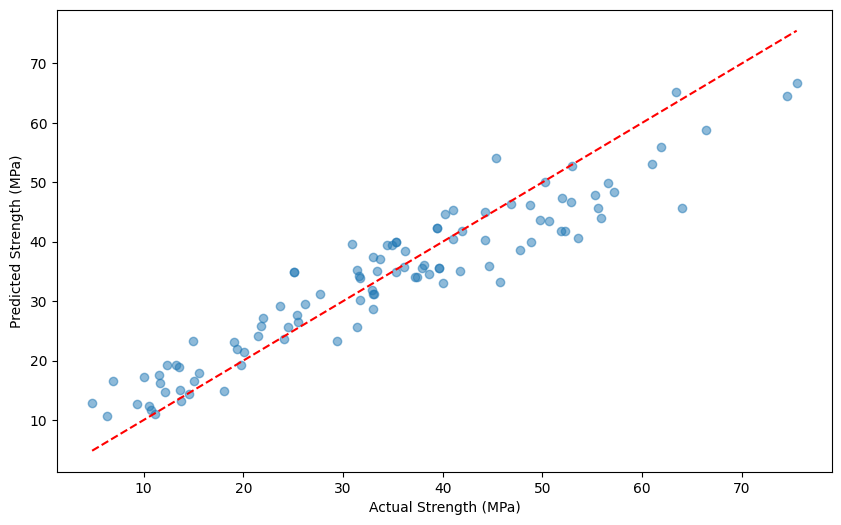

In [62]:
# plotting
y_holdout = y_holdout.flatten()
holdout_preds = holdout_preds.flatten()

plt.figure(figsize=(10, 6))
plt.scatter(y_holdout, holdout_preds, alpha=0.5)
min_val = min(y_holdout.min(), holdout_preds.min())
max_val = max(y_holdout.max(), holdout_preds.max())

plt.plot([min_val, max_val], [min_val, max_val], color='red', linestyle='--')
plt.xlabel("Actual Strength (MPa)")
plt.ylabel("Predicted Strength (MPa)")
plt.show()

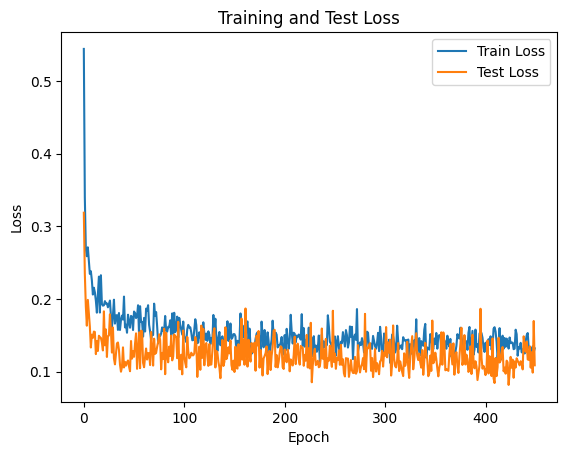

In [66]:
plt.plot(train_losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training and Test Loss')
plt.legend()
plt.show()
